# Grid, PV, battery and a demand

48 hours, one electricity bus. PV covers the middle of the day, the battery
shifts energy into the expensive evening hours.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from esmkit import SystemSpec, build_system, node_results, objective_value, solve

In [2]:
index = pd.date_range("2010-01-01", periods=48, freq="h")

import_price = np.where((index.hour >= 17) & (index.hour < 21), 0.40, 0.12)
pv_yield = np.clip(np.sin((index.hour - 6) / 12 * np.pi), 0, None)
demand = np.where((index.hour >= 18) & (index.hour < 22), 2.5, 1.0)

inputs = {"import_price": import_price, "pv_yield": pv_yield, "demand": demand}

In [3]:
spec = SystemSpec()
spec.add_bus("elec", carrier="electricity")

spec.add_component(
    "grid", "grid", bus="elec", import_price="@import_price", export_price=0.08
)
spec.add_component("pv", "pv", bus="elec", specific_yield="@pv_yield", capacity=5.0)
spec.add_component("battery", "battery", bus_in="elec", bus_out="elec", capacity=10.0)
spec.add_component("demand", "demand", bus="elec", profile="@demand")

spec

SystemSpec(1 buses, 4 components)

In [4]:
es, nodes = build_system(spec, inputs, index)
model, _ = solve(es)
results = node_results(model, nodes, index=index)

generation = results["pv"]["out_elec"]
consumption = results["demand"]["in_elec"]
imported = results["grid"]["out_elec"]
exported = results["grid"]["in_elec"]
charge = results["battery"]["in_elec"]
discharge = results["battery"]["out_elec"]

`storage_content` is one value longer than the time index (it is a state at the interval bounds), so the last point is dropped here.

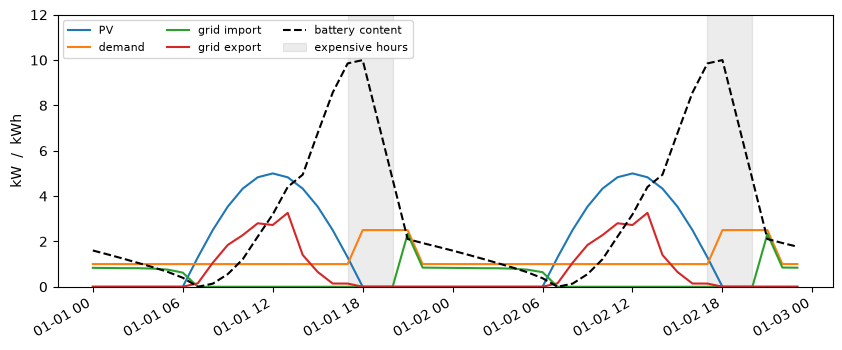

In [5]:
soc = results["battery"]["storage_content"].to_numpy()[: len(index)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(index, generation, label="PV")
ax.plot(index, consumption, label="demand")
ax.plot(index, imported, label="grid import")
ax.plot(index, exported, label="grid export")
ax.plot(index, soc, label="battery content", linestyle="--", color="black")
ax.fill_between(index, 0, 12, where=(index.hour >= 17) & (index.hour < 21),
                color="grey", alpha=0.15, label="expensive hours")
ax.set_ylabel("kW  /  kWh")
ax.set_ylim(0, 12)
ax.legend(loc="upper left", fontsize=8, ncol=3)
fig.autofmt_xdate()
plt.show()

In [6]:
evening = (index.hour >= 17) & (index.hour < 21)

print("objective                : {:8.2f} EUR".format(objective_value(model)))
print("PV generation            : {:8.2f} kWh".format(generation.sum()))
print("demand                   : {:8.2f} kWh".format(consumption.sum()))
print("grid import              : {:8.2f} kWh".format(imported.sum()))
print("grid export              : {:8.2f} kWh".format(exported.sum()))
print("battery charged          : {:8.2f} kWh".format(charge.sum()))
print("battery discharged       : {:8.2f} kWh".format(discharge.sum()))
print()
print("import in expensive hours: {:8.2f} kWh".format(imported.to_numpy()[evening].sum()))
print("battery covers           : {:8.2f} kWh".format(discharge.to_numpy()[evening].sum()))

objective                :    -0.35 EUR
PV generation            :    75.96 kWh
demand                   :    60.00 kWh
grid import              :    19.00 kWh
grid export              :    32.90 kWh
battery charged          :    21.05 kWh
battery discharged       :    19.00 kWh

import in expensive hours:     0.00 kWh
battery covers           :    15.00 kWh
